# Trabajo Práctico 2 - Problema 1: Diagnóstico de Cáncer de Mama

## Introducción

Este notebook aborda el problema de clasificación binaria para el diagnóstico de tumores mamarios (benignos vs malignos) utilizando regresión logística implementada desde cero.

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('../src/')
from preprocessing import *
from metrics import *
from models import *
from utils import *
from balanced import *

## 1. Carga y Exploración de Datos

In [23]:
from IPython.display import Markdown, display

balanced_dev = pd.read_csv('../data1/cell_diagnosis_dev.csv')
balanced_test = pd.read_csv('../data1/cell_diagnosis_test.csv')

In [24]:
def show_basic_info(df, name):
    display(Markdown(f"### {name}"))
    display(Markdown(f"**Forma del dataset**: {df.shape}"))
    display(Markdown(f"**Columnas del dataset**: {df.columns.tolist()}"))
    display(Markdown("**Primeras filas del dataset**:"))
    display(df.head())
    display(Markdown("**Información del dataset**:"))
    display(df.info())
    display(Markdown("**Estadísticas descriptivas**:"))
    display(df.describe())
    display(Markdown("**Distribución de clases**:"))
    display(df['Diagnosis'].value_counts(normalize=True))

# show_basic_info(balanced_dev, "Datos Balanceados (Desarrollo)")

In [25]:
# balanced_dev.drop(columns=["Diagnosis"]).hist(figsize=(15, 10), log=True)
# plt.tight_layout()
# plt.show()

se puede ver que casi todas las variables forman dos clusters

In [26]:
# categorical_columns = ["CellType", "GeneticMutation"]
# fig, axes = plt.subplots(nrows=1, ncols=len(categorical_columns), figsize=(12, 6))

# for i, col in enumerate(categorical_columns):
#     value_counts = balanced_dev[col].value_counts(dropna=False)
#     value_counts.index = value_counts.index.fillna('NaN')
#     value_counts.plot(kind="bar", ax=axes[i])
#     axes[i].set_title(f"Distribución de {col}")
#     axes[i].set_xlabel(col)
#     axes[i].set_ylabel("Frecuencia")

# plt.tight_layout()
# plt.show()

In [27]:
# numeric_df = balanced_dev.select_dtypes(include=[np.number]) 
# corr = numeric_df.corr()

# fig, axes = plt.subplots(1, 1, figsize=(10, 8))
# sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', ax=axes)
# plt.tight_layout()
# plt.show()

In [28]:
# sns.pairplot(balanced_dev, hue="Diagnosis", diag_kind="kde", markers=["o", "s"])
# plt.suptitle("Pairplot de variables numéricas (Cluster 0)", y=1.02)
# plt.show()

In [ ]:
clean_df = preprocess_data(balanced_dev, underlimit=0.15, uperlimit=0.85)

In [30]:
# clean_df.drop(columns=["Diagnosis", "GeneticMutation", "Epthlial", "Mesnchymal"]).hist(figsize=(15, 10), log=True, bins=20)
# plt.tight_layout()
# plt.show()

In [31]:
# sns.pairplot(clean_df.drop(columns=["GeneticMutation", "Epthlial", "Mesnchymal"]), hue="Diagnosis", diag_kind="kde", markers=["o", "s"])
# plt.suptitle("Pairplot de variables numéricas", y=1.02)
# plt.show()

## 2. Preprocesamiento de Datos

In [32]:
X_train, X_val, y_train, y_val, means, stds = split_and_normalize(clean_df, target_column='Diagnosis', exclude_cols=["Epthlial", "Mesnchymal", "GeneticMutation"])

In [33]:
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_val)
y_pred_proba = model.predict_proba(X_val)


Classification Report
              precision    recall  f1-score   support

         0.0       0.97      0.90      0.93       174
         1.0       0.90      0.97      0.93       150

    accuracy                           0.93       324
   macro avg       0.93      0.93      0.93       324
weighted avg       0.93      0.93      0.93       324


--- Confusion Matrix ---


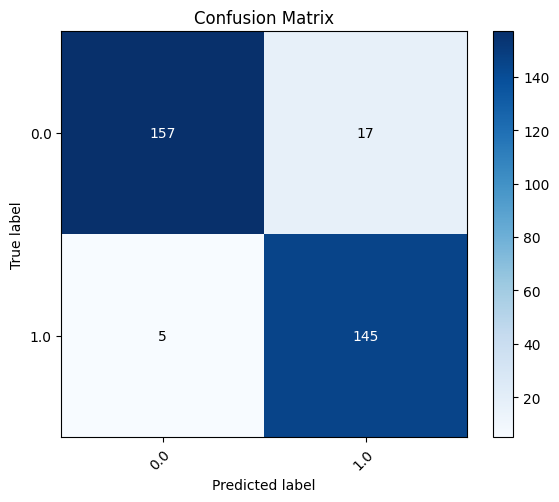

--- Performance Curves  ---
Binary case detected (Classes: ['0.0', '1.0']). Positive label assumed: '1'


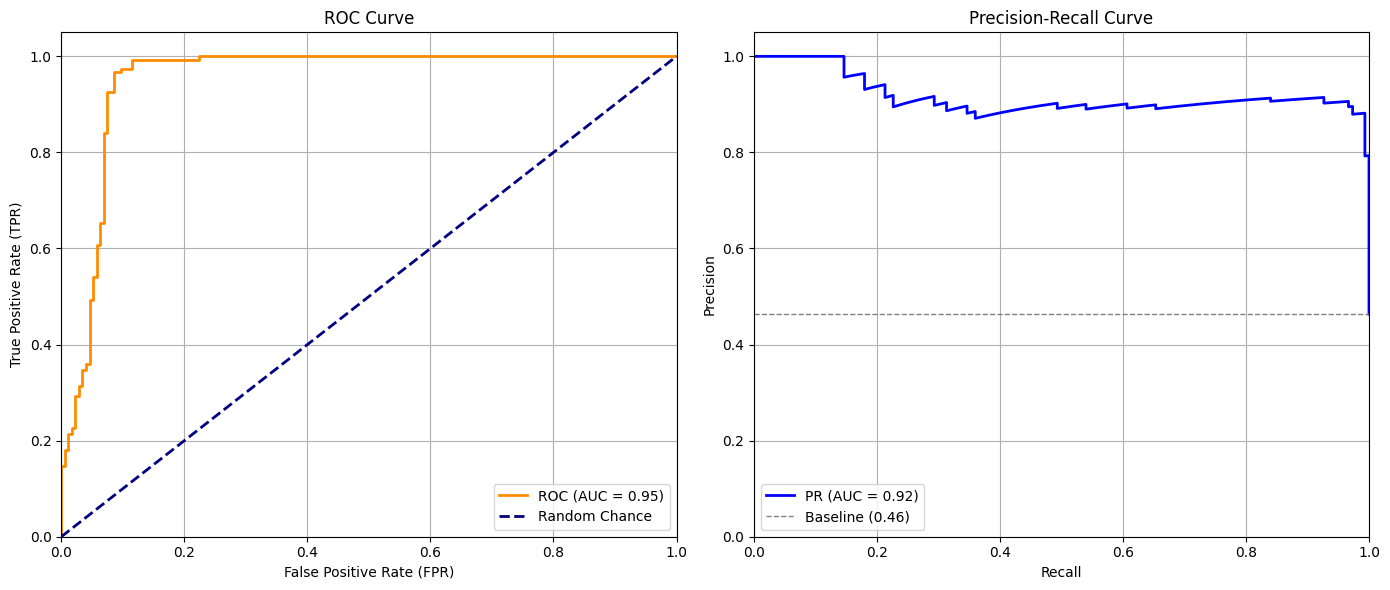

In [34]:
display_full_metrics(y_val, y_pred, y_pred_proba)

## 3. Optimización de Hiperparámetros

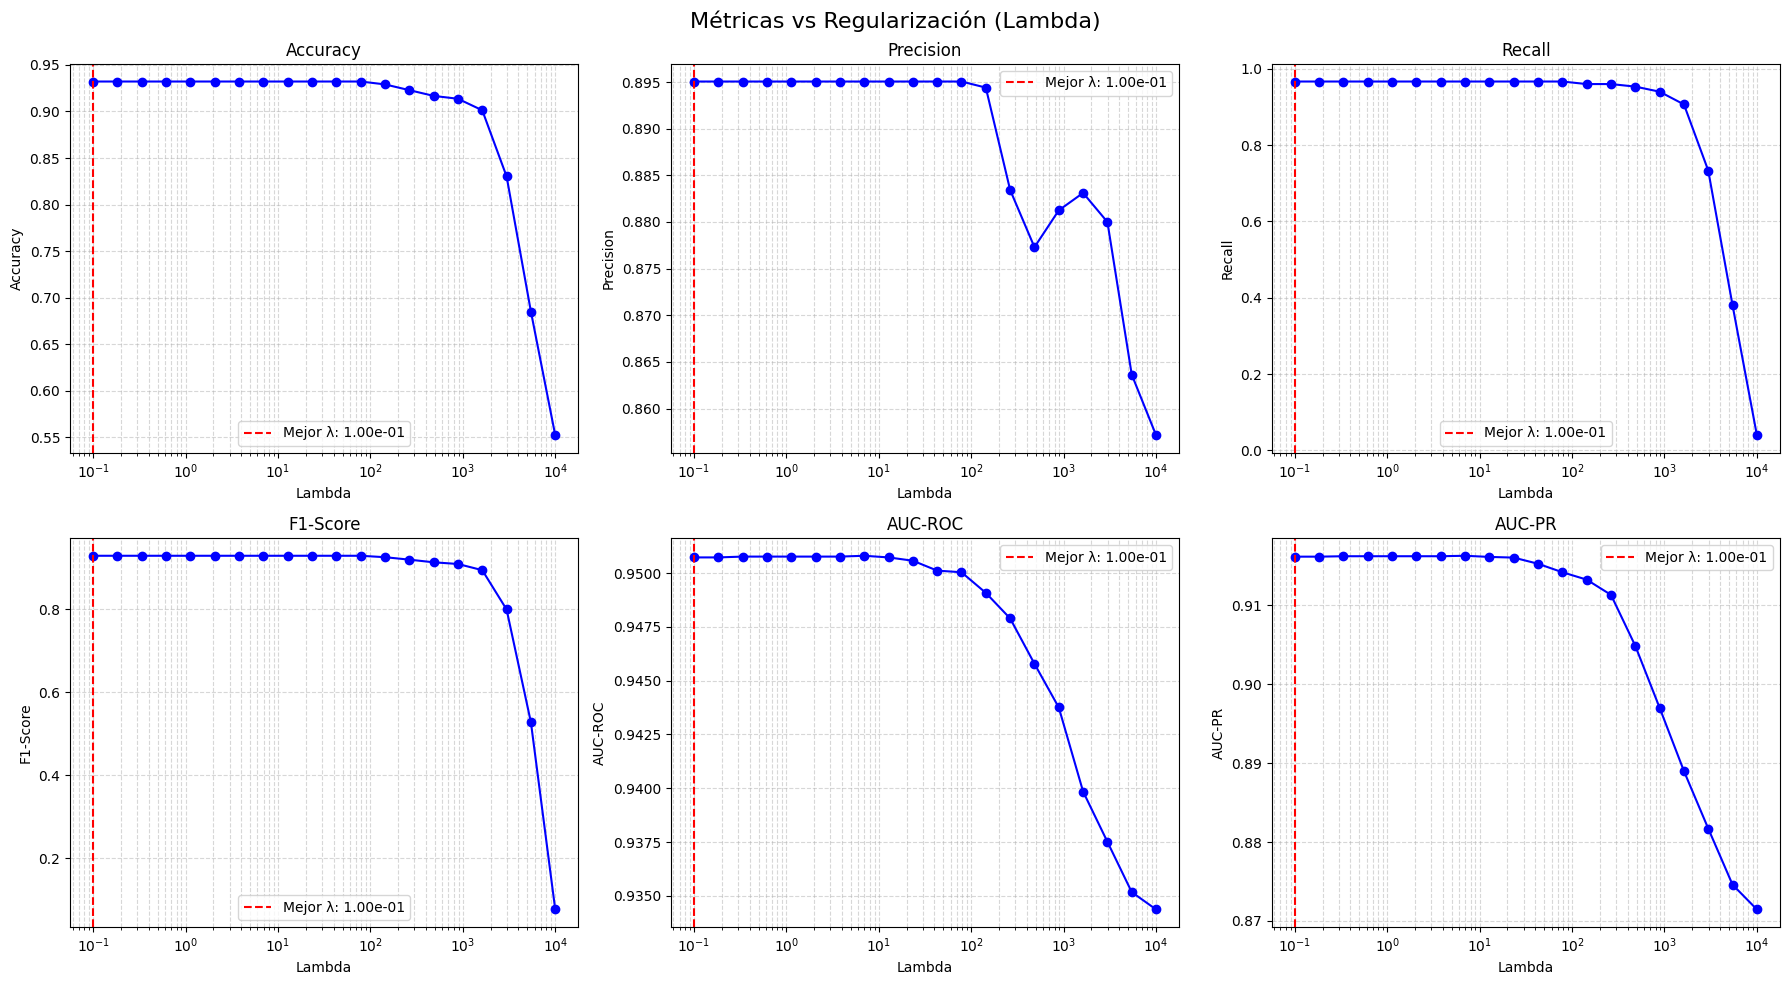


Mejor λ: 1.00e-01 con F1-Score: 0.9295


In [35]:
lambda_values = np.logspace(-1, 4, num=20) 

all_metrics = []
best_f1 = -1
best_lambda = None

for lambda_ in lambda_values:
    model = LogisticRegression(reg_lambda=lambda_)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    y_pred_proba = model.predict_proba(X_val)
    
    metrics = calculate_metrics(y_val, y_pred, y_pred_proba)
    metrics['probabilities'] = y_pred_proba
    metrics['lambda'] = lambda_
    all_metrics.append(metrics)
        
    if metrics['f1_score'] > best_f1:
        best_f1 = metrics['f1_score']
        best_lambda = lambda_

lambdas = [m['lambda'] for m in all_metrics]
accuracy = [m['accuracy'] for m in all_metrics]
precision = [m['precision'] for m in all_metrics]
recall = [m['recall'] for m in all_metrics]
f1_scores = [m['f1_score'] for m in all_metrics]
auc_roc = [m['auc_roc'] for m in all_metrics]
auc_pr = [m['auc_pr'] for m in all_metrics]

fig, axs = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Métricas vs Regularización (Lambda)', fontsize=16)

metrics_to_plot = [
    ('Accuracy', accuracy),
    ('Precision', precision),
    ('Recall', recall),
    ('F1-Score', f1_scores),
    ('AUC-ROC', auc_roc),
    ('AUC-PR', auc_pr)
]

for i, (title, data) in enumerate(metrics_to_plot):
    ax = axs[i//3, i%3]
    ax.semilogx(lambdas, data, 'b-', marker='o')
    ax.axvline(best_lambda, color='r', linestyle='--', 
              label=f'Mejor λ: {best_lambda:.2e}')
    ax.set_title(title)
    ax.set_xlabel('Lambda')
    ax.set_ylabel(title)
    ax.grid(True, which='both', linestyle='--', alpha=0.5)
    ax.legend()

plt.tight_layout()
plt.show()

print(f"\nMejor λ: {best_lambda:.2e} con F1-Score: {best_f1:.4f}")

In [ ]:
best_model = LogisticRegression(reg_lambda=best_lambda)
df, means, stds = normalize(clean_df, exclude_cols=["Epthlial", "Mesnchymal", "GeneticMutation", "Diagnosis"])
df = handle_missing_values(df)
best_model.fit( df.drop(columns=["Diagnosis"]), df["Diagnosis"])
save_model(best_model, "Diagnostico_balance_model.pkl")

Model successfully saved to ../modelos/best_model.pkl


In [ ]:
test_set = handle_categorical_features(balanced_test)
test_set , _,_ = normalize(test_set, means, stds, exclude_cols=["Epthlial", "Mesnchymal", "GeneticMutation", "Diagnosis"])
test_set = handle_missing_values(test_set, train_df=df)


Classification Report
              precision    recall  f1-score   support

         0.0       0.86      0.88      0.87       102
         1.0       0.85      0.82      0.83        83

    accuracy                           0.85       185
   macro avg       0.85      0.85      0.85       185
weighted avg       0.85      0.85      0.85       185


--- Confusion Matrix ---


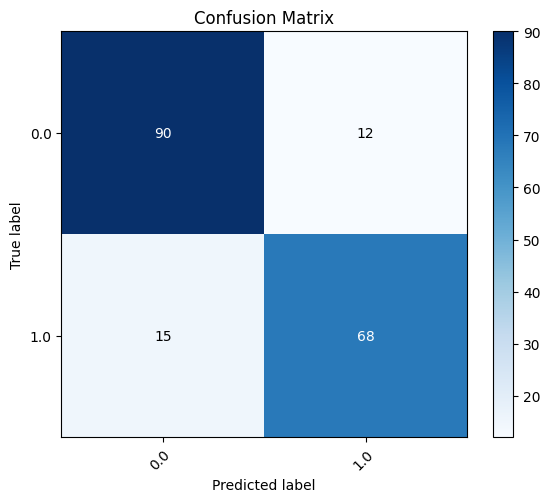

--- Performance Curves  ---
Binary case detected (Classes: ['0.0', '1.0']). Positive label assumed: '1'


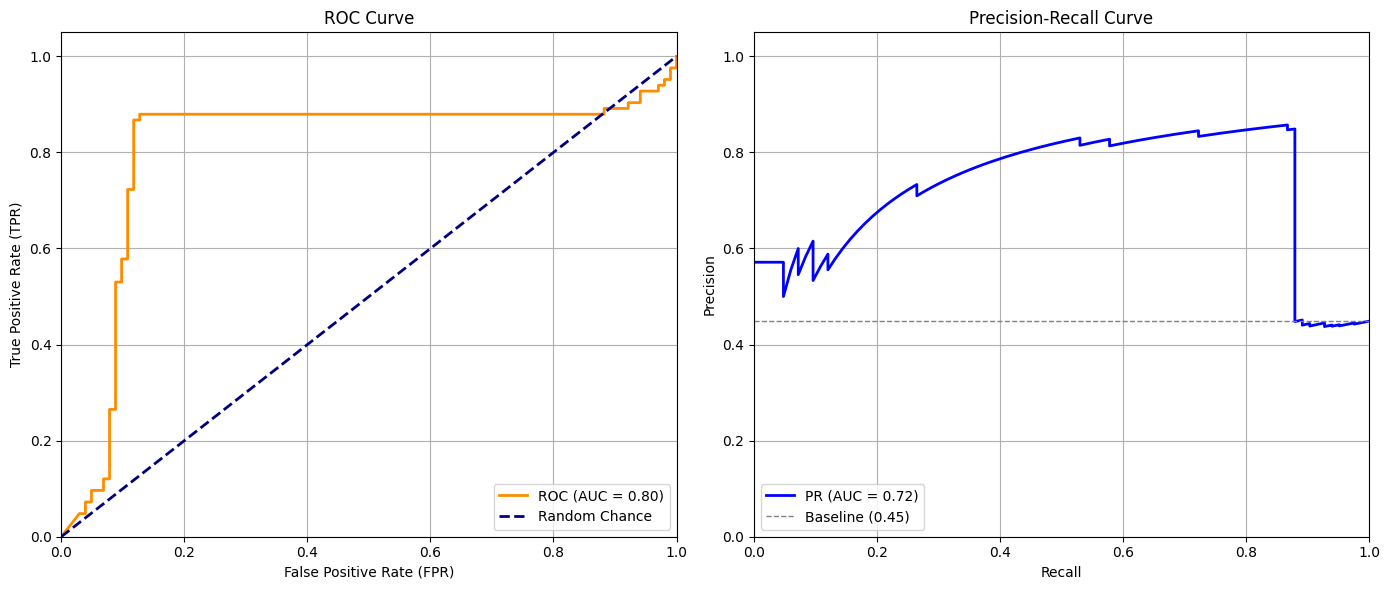

In [38]:
y_test_pred = best_model.predict(test_set.drop(columns=["Diagnosis"]))
y_test_pred_proba = best_model.predict_proba(test_set.drop(columns=["Diagnosis"]))
display_full_metrics(balanced_test["Diagnosis"], y_test_pred, y_test_pred_proba)

## 4. Evaluación del Modelo con Datos Desbalanceados

In [39]:
imbalanced_dev = pd.read_csv('../data1/cell_diagnosis_dev_imbalanced.csv')
imbalanced_test = pd.read_csv('../data1/cell_diagnosis_test_imbalanced.csv')

show_basic_info(imbalanced_dev, "Datos Desbalanceados (Desarrollo)")

### Datos Desbalanceados (Desarrollo)

**Forma del dataset**: (1218, 15)

**Columnas del dataset**: ['CellSize', 'CellShape', 'NucleusDensity', 'ChromatinTexture', 'CytoplasmSize', 'CellAdhesion', 'MitosisRate', 'NuclearMembrane', 'GrowthFactor', 'OxygenSaturation', 'Vascularization', 'InflammationMarkers', 'Diagnosis', 'CellType', 'GeneticMutation']

**Primeras filas del dataset**:

,CellSize,CellShape,NucleusDensity,ChromatinTexture,CytoplasmSize,CellAdhesion,MitosisRate,NuclearMembrane,GrowthFactor,OxygenSaturation,Vascularization,InflammationMarkers,Diagnosis,CellType,GeneticMutation
0,67.663374,0.513293,1.483674,NaN,NaN,0.476990,3.325950,2.449179,58.451676,NaN,5.544034,44.252979,0.0,Epthlial,Absnt
1,-100.000000,0.508854,1.458626,NaN,26.553677,0.499220,3.274258,2.567775,-50.000000,79.573324,5.556110,42.430723,0.0,NaN,Presnt
2,61.101997,0.466692,1.487378,23.033832,26.190955,0.459161,NaN,2.472128,67.187650,78.235757,5.187052,40.741895,0.0,???,Presnt
3,69.867684,0.519679,1.371829,20.910025,27.896494,0.518146,2.736139,2.400920,60.788227,79.562821,5.035683,NaN,1.0,Epthlial,Absnt
4,65.391094,0.489866,1.574212,19.964398,25.472444,0.452596,NaN,2.581605,59.699000,82.807669,5.109881,NaN,0.0,Epthlial,Presnt


...

None

**Estadísticas descriptivas**:

,CellSize,CellShape,NucleusDensity,ChromatinTexture,CytoplasmSize,CellAdhesion,MitosisRate,NuclearMembrane,GrowthFactor,OxygenSaturation,Vascularization,InflammationMarkers,Diagnosis
count,982.000000,981.000000,998.000000,1006.000000,973.000000,1004.000000,978.000000,993.000000,988.000000,998.000000,988.000000,999.000000,1218.000000
mean,79.555996,0.598320,2.119365,26.175980,33.082141,0.554118,5.717573,2.896795,72.221366,93.240958,5.920371,49.316550,0.249589
std,89.853115,0.580204,4.879884,24.336051,32.333310,0.641056,11.985762,2.831194,76.313241,81.907593,5.486086,46.078477,0.432953
min,-100.000000,-1.413038,-3.000000,15.776662,5.000000,-4.461755,-5.000000,-3.438990,-50.000000,-10.000000,-0.997057,0.000000,0.000000
25%,65.969773,0.477829,1.416244,21.264939,25.907336,0.456123,2.890828,2.324643,57.325664,79.116121,4.781688,38.916909,0.000000
50%,68.331328,0.497931,1.463350,22.051707,27.252767,0.475207,3.296181,2.472245,59.536450,79.940819,5.074992,42.224414,0.000000
75%,71.488821,0.522337,1.495688,22.809761,29.639382,0.493890,3.470776,2.553760,62.259275,81.019424,5.359340,44.761177,0.000000
max,1000.000000,4.912125,50.000000,228.929540,299.350559,5.029925,100.000000,24.871762,563.622684,758.487171,54.512433,440.902261,1.000000


**Distribución de clases**:

Diagnosis
0.0    0.750411
1.0    0.249589
Name: proportion, dtype: float64

In [40]:
imbalanced_dev = handle_categorical_features(imbalanced_dev)
imbalanced_dev = clean_data(imbalanced_dev)
imbalanced_dev.describe()

,CellSize,CellShape,NucleusDensity,ChromatinTexture,CytoplasmSize,CellAdhesion,MitosisRate,NuclearMembrane,GrowthFactor,OxygenSaturation,Vascularization,InflammationMarkers,Diagnosis,GeneticMutation,Epthlial,Mesnchymal
count,937.000000,941.000000,907.000000,976.000000,917.000000,982.000000,890.000000,967.000000,908.000000,974.000000,969.000000,975.000000,1183.000000,1183.000000,1017.000000,1017.000000
mean,79.654312,0.589745,1.451918,25.220485,27.691657,0.463592,3.181915,2.403604,59.699269,77.860659,5.023133,41.488169,0.252747,0.519865,0.351032,0.300885
std,71.568858,0.530113,0.052101,21.687291,2.332852,0.078661,0.319995,0.317119,3.006497,11.722676,0.631984,4.968481,0.434771,0.499817,0.477528,0.458868
min,55.597852,0.389644,1.252846,18.937205,22.405899,-0.446175,2.399168,-0.343899,50.434591,-1.000000,0.082936,0.000000,0.000000,0.000000,0.000000,0.000000
25%,66.204299,0.478931,1.416349,21.255445,25.924964,0.453729,2.875996,2.302492,57.428085,78.976803,4.762448,38.588847,0.000000,0.000000,0.000000,0.000000
50%,68.433237,0.497931,1.460935,22.032652,27.211047,0.473005,3.270893,2.463061,59.497788,79.827748,5.052429,41.962784,0.000000,1.000000,0.000000,0.000000
75%,71.537528,0.520980,1.490119,22.786453,29.451856,0.491664,3.433398,2.543788,62.013536,80.784833,5.327646,44.425030,1.000000,1.000000,1.000000,1.000000
max,705.105627,4.912125,1.594042,228.929540,37.614354,0.814522,4.310250,4.849105,69.736403,97.436755,9.686430,82.216630,1.000000,1.000000,1.000000,1.000000


In [ ]:
X_train, X_val, y_train, y_val, means, stds = split_and_normalize(imbalanced_dev, target_column='Diagnosis', exclude_cols=["Epthlial", "Mesnchymal", "GeneticMutation"], stratified=True)

In [47]:
strategies = {
    'Sin rebalanceo': (X_train, y_train),
    'Undersampling': random_undersample(X_train, y_train),
    'Oversampling duplicate': duplicate_oversample(X_train, y_train),
    'Oversampling SMOTE': SMOTE(X_train, y_train),
    'Cost re-weighting': (X_train, y_train)
}

n_class_0 = np.sum(y_train == 0)
n_class_1 = np.sum(y_train == 1)
class_weights = {
    0: n_class_1/n_class_0,
    1: 1.0           
}

results = {}

for strategy, (X_res, y_res) in strategies.items():
    if strategy == 'Cost re-weighting':
        model = LogisticRegression(reg_lambda=best_lambda, class_weight=class_weights)
    else:
        model = LogisticRegression(reg_lambda=best_lambda)

    model.fit(X_res, y_res)
    y_pred = model.predict(X_val)
    y_proba = model.predict_proba(X_val)[:, 1]
    metrics = calculate_metrics(y_val, y_pred, y_proba)
    metrics['roc_curve'] = roc_curve(y_val, y_proba)
    metrics['pr_curve'] = pr_curve(y_val, y_proba)
    results[strategy] = metrics

print("\n=== Tabla de Resultados ===")
print("{:<25} {:<10} {:<10} {:<10} {:<10} {:<10} {:<10}".format(
    "Modelo", "Accuracy", "Precision", "Recall", "F-Score", "AUC-ROC", "AUC-PR"))

for strategy in ['Sin rebalanceo', 'Undersampling', 'Oversampling duplicate', 
                'Oversampling SMOTE', 'Cost re-weighting']:
    m = results[strategy]
    print("{:<25} {:<10.4f} {:<10.4f} {:<10.4f} {:<10.4f} {:<10.4f} {:<10.4f}".format(
        strategy, m['accuracy'], m['precision'], m['recall'], 
        m['f1_score'], m['auc_roc'], m['auc_pr']))


=== Tabla de Resultados ===
Modelo                    Accuracy   Precision  Recall     F-Score    AUC-ROC    AUC-PR    
Sin rebalanceo            0.9156     0.7857     0.9167     0.8462     0.9650     0.8754    
Undersampling             0.9030     0.7229     1.0000     0.8392     0.9599     0.8606    
Oversampling duplicate    0.9241     0.7692     1.0000     0.8696     0.9661     0.8816    
Oversampling SMOTE        0.9198     0.7595     1.0000     0.8633     0.9647     0.8725    
Cost re-weighting         0.9114     0.7407     1.0000     0.8511     0.9639     0.8735    


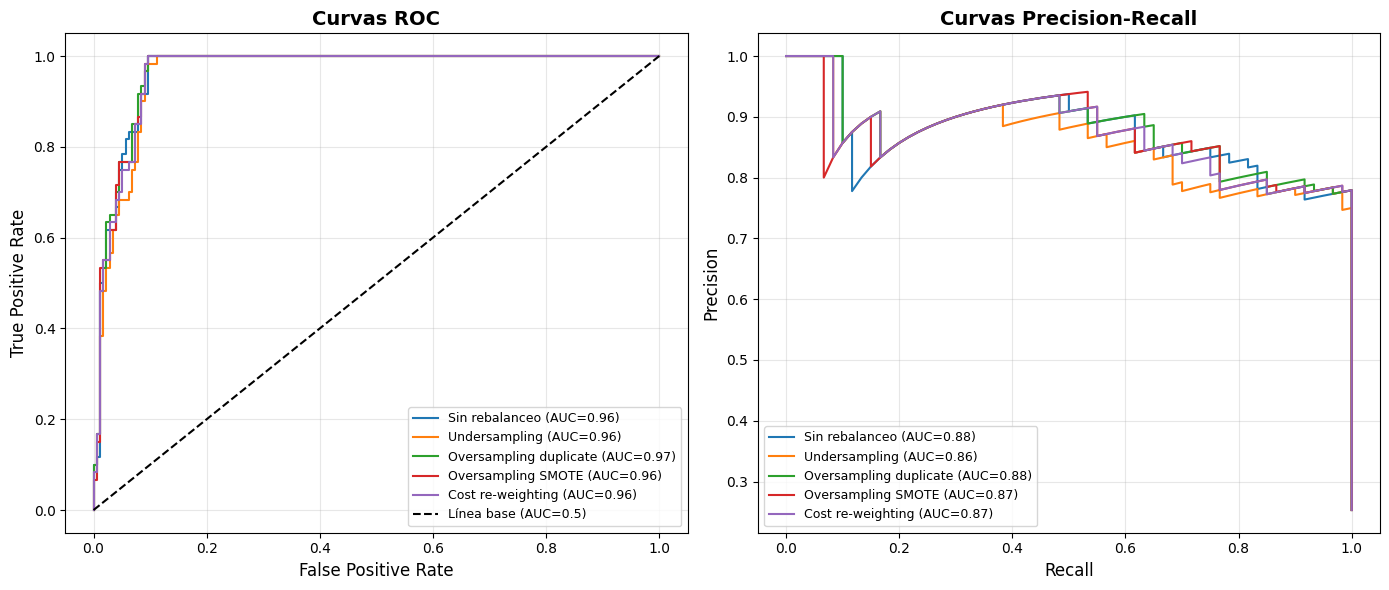

In [48]:
# Graficar curvas
plt.figure(figsize=(14, 6))

# Curva ROC
plt.subplot(1, 2, 1)
for strategy, m in results.items():
    fpr, tpr, _ = m['roc_curve']
    plt.plot(fpr, tpr, label=f'{strategy} (AUC={m["auc_roc"]:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Línea base (AUC=0.5)')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Curvas ROC', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=9)  # Leyenda dentro, esquina inferior derecha
plt.grid(True, alpha=0.3)

# Curva Precision-Recall
plt.subplot(1, 2, 2)
for strategy, m in results.items():
    precision, recall, _ = m['pr_curve']
    plt.plot(recall, precision, label=f'{strategy} (AUC={m["auc_pr"]:.2f})')
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Curvas Precision-Recall', fontsize=14, fontweight='bold')
plt.legend(loc='lower left', fontsize=9)  # Leyenda dentro, esquina inferior izquierda
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
best_model = LogisticRegression(reg_lambda=best_lambda)
df, means, stds = normalize(df, exclude_cols=["Epthlial", "Mesnchymal", "GeneticMutation", "Diagnosis"])
df = handle_missing_values(imbalanced_dev)
X, y = duplicate_oversample(df.drop(columns=["Diagnosis"]), df["Diagnosis"])
best_model.fit(X, y)
save_model(best_model, "Diagnostico_imbalance_model.pkl")

Model successfully saved to best_model.pkl


In [60]:
test_set = handle_categorical_features(imbalanced_test)
test_set , _,_ = normalize(test_set, means, stds, exclude_cols=["Epthlial", "Mesnchymal", "GeneticMutation", "Diagnosis"])
test_set = handle_missing_values(test_set, train_df=df)


Classification Report
              precision    recall  f1-score   support

         0.0       0.81      0.62      0.70       102
         1.0       0.33      0.56      0.41        34

    accuracy                           0.60       136
   macro avg       0.57      0.59      0.56       136
weighted avg       0.69      0.60      0.63       136


--- Confusion Matrix ---


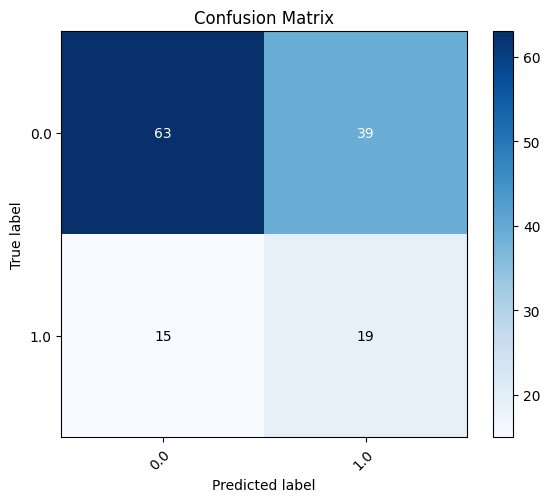

--- Performance Curves  ---
Binary case detected (Classes: ['0.0', '1.0']). Positive label assumed: '1'


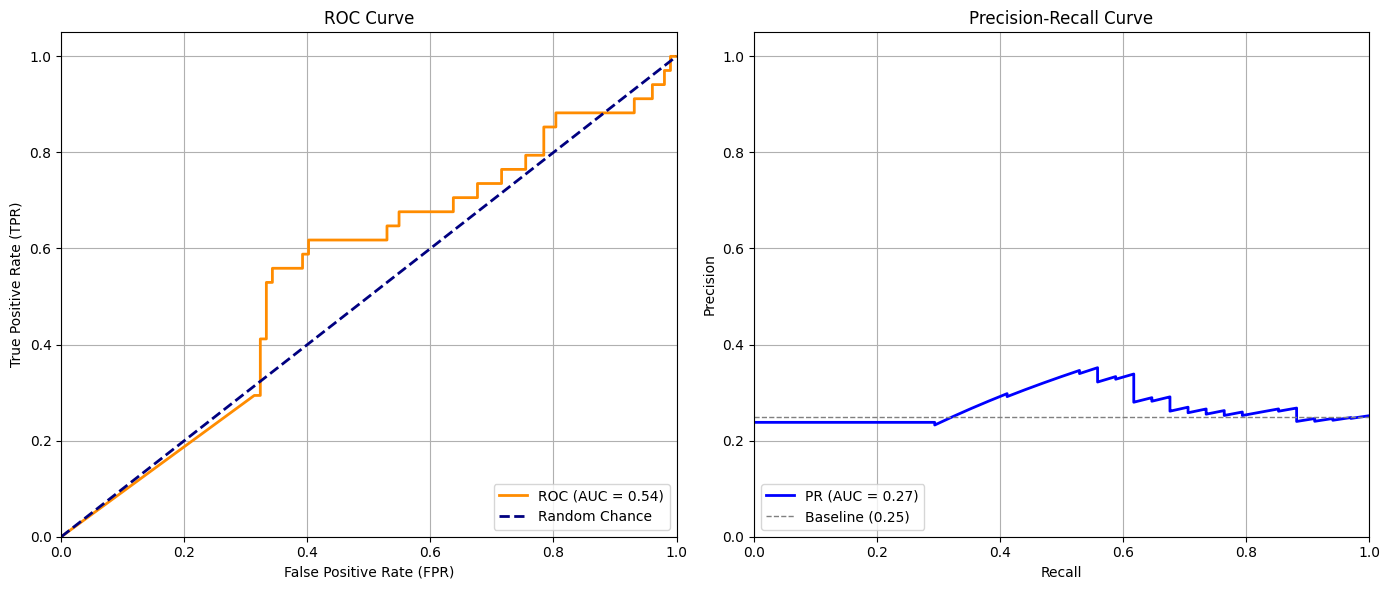

In [61]:
y_test_pred = best_model.predict(test_set.drop(columns=["Diagnosis"]))
y_test_pred_proba = best_model.predict_proba(test_set.drop(columns=["Diagnosis"]))
display_full_metrics(imbalanced_test["Diagnosis"], y_test_pred, y_test_pred_proba)